In [32]:
import numpy as np
import yfinance as yf
import pandas as pd
import warnings
from datetime import date
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from models import FeedForward, LSTM, Hybrid
from feature_engineering import FeatureEngineer

warnings.filterwarnings('ignore')

In [33]:
# READ S&P 500 TICKERS FROM TXT
def load_simple_ticker_list(filename='sp500_tickers.txt'):
    """Load tickers from simple text file (one per line)"""
    try:
        with open(filename, 'r') as f:
            tickers = [line.strip() for line in f.readlines() if line.strip()]
        return tickers
    except FileNotFoundError:
        print(f"❌ File {filename} not found.")
        return []

tickers = load_simple_ticker_list('sp500_tickers.txt')

In [34]:
# S&P 500 STOCK PROCESSING WITH LIMITS
import gc  # For garbage collection

# Configuration
sp500_tickers = tickers  # From loaded file
period = "10y"

# STOCK LIMIT CONFIGURATION
USE_FULL_DATASET = False  # Set to True when ready for full run
STOCK_LIMIT = 5          # Limit for testing (set to desired number)

# Apply stock limit
if USE_FULL_DATASET:
    processing_tickers = sp500_tickers
    print(f"🚀 FULL DATASET MODE: Processing all {len(processing_tickers)} S&P 500 stocks")
else:
    processing_tickers = sp500_tickers[:STOCK_LIMIT]
    print(f"🧪 TEST MODE: Processing first {len(processing_tickers)} stocks")

print("=" * 60)
print(f"📊 Dataset: S&P 500")
print(f"🎯 Stocks to process: {len(processing_tickers)}")
print("=" * 60)

all_data = []
total_tickers = len(processing_tickers)

# For progress tracking
successful_stocks = 0
failed_stocks = 0

# Instantiate the feature engineer
feature_engineer = FeatureEngineer()

for idx, ticker in enumerate(processing_tickers, 1):
    try:
        # Download data
        stock_data = yf.download(ticker, period=period, progress=False)
        
        if stock_data.empty:
            print(f"\r❌ [{idx}/{total_tickers}] {ticker}: No data available" + " " * 20)
            failed_stocks += 1
            continue

        # Generate features using the FeatureEngineer class
        features = feature_engineer.create_features(stock_data, ticker)
        
        # Add target and ticker
        features['Target'] = stock_data['Close'].shift(-1)  # Next day's close
        features['Ticker'] = ticker
        
        # Remove infinite and NaN values
        clean_data = features.dropna()
        
        if len(clean_data) > 0:
            all_data.append(clean_data)
            successful_stocks += 1
            if idx % 25 == 0 or idx == total_tickers: # Print every 25 ticker or the last
                print(f"✅ [{idx}/{total_tickers}] {ticker}: {len(clean_data):,} samples")
        else:
            print(f"⚠️ [{idx}/{total_tickers}] {ticker}: No clean data after processing")
            failed_stocks += 1
        
        # GARBAGE COLLECTION
        if idx % 25 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            print(f"\r🧹 [{idx}/{total_tickers}] Memory cleanup completed" + " " * 30)
            
    except Exception as e:
        print(f"\r❌ [{idx}/{total_tickers}] {ticker}: Error - {str(e)}")
        failed_stocks += 1
        continue

# Final cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Clear progress line and show completion
print("=" * 60)
print(f"✅ Successful: {successful_stocks} stocks")
print(f"❌ Failed: {failed_stocks} stocks")
print(f"📊 Success rate: {successful_stocks/(successful_stocks+failed_stocks)*100:.1f}%" if (successful_stocks+failed_stocks) > 0 else "0.0%")
print("=" * 60)

# Combine all data
if all_data:
    ml_data = pd.concat(all_data, ignore_index=True)
    feature_count = len([col for col in ml_data.columns if col not in ['Target', 'Ticker']])
    
    print(f"📊 Total samples: {len(ml_data):,}")
    print(f"🔧 Features: {feature_count}")
    print(f"📈 Stocks: {len(ml_data['Ticker'].unique())}")
    print(f"💾 Memory: {ml_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"📅 Date range: {period}")
    
    # Show sample data
    sample_cols = ['Price_Change', 'RSI_14', 'MACD', 'Volume_Ratio_10', 'Target', 'Ticker']
    print(f"\n📋 SAMPLE DATA:")
    print(ml_data[sample_cols].head(3).round(4))
    
    print(f"\n✅ Ready for ML with {feature_count} features from {len(ml_data['Ticker'].unique())} stocks!")
    
else:
    print("\n❌ ERROR: No data processed successfully!")
    ml_data = pd.DataFrame()

🧪 TEST MODE: Processing first 5 stocks
📊 Dataset: S&P 500
🎯 Stocks to process: 5
✅ [5/5] ACN: 2,514 samples
✅ Successful: 5 stocks
❌ Failed: 0 stocks
📊 Success rate: 100.0%
📊 Total samples: 12,570
🔧 Features: 48
📈 Stocks: 5
💾 Memory: 5.4 MB
📅 Date range: 10y

📋 SAMPLE DATA:
   Price_Change   RSI_14    MACD  Volume_Ratio_10   Target Ticker
0        0.0023  33.8393 -1.4135           1.1072  93.0227    MMM
1        0.0023  33.8393 -1.4135           1.1072  91.3948    MMM
2       -0.0175  33.8393 -1.4135           1.1072  92.0172    MMM

✅ Ready for ML with 48 features from 5 stocks!


In [35]:
#Device Detection

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon GPU")
else:
    device = torch.device('cpu')
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4060


In [36]:
# DATA PREPARATION FOR PYTORCH
print("📊 PREPARING DATA FOR PYTORCH")
print("=" * 40)

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

def prep_training_data(ml_data, sequence_length=10, test_size=0.2, scale_target=True, log_transform_target=True):
    """
    Prepare data for PyTorch training
    
    Args:
        ml_data: Your dataset
        sequence_length: Number of days to look back (for LSTM)
        test_size: Fraction for testing
        scale_target: Whether to scale the target variable
        log_transform_target: Whether to transform data in log format
    """
    print(f"📋 Input data shape: {ml_data.shape}")
    
    # Separate features and target
    feature_cols = [col for col in ml_data.columns if col not in ['Target', 'Ticker']]
    features = ml_data[feature_cols]
    
    # 🎯 KEY FIX: Predict RETURNS not PRICES
    prices = ml_data['Target']
    current_prices = prices.shift(1)  # Previous day's price
    returns = (prices - current_prices) / current_prices  # Return calculation
    
    # Remove NaN from the returns calculation
    valid_mask = ~(returns.isna() | current_prices.isna())
    features = features[valid_mask]
    target = returns[valid_mask]

    if log_transform_target:
            print("Applying log1p transformation to the target variable.")
            target = np.log1p(target) # log1p is log(1+x), safer for values near zero

    # --- Split data using train_test_split WITHOUT shuffling ---
    X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
        features, 
        target, 
        test_size=test_size,
        shuffle=False, # CRUCIAL: Do not shuffle time-series data
        random_state=42 # Ensures reproducibility, though not strictly needed with shuffle=False
    )

    # --- FIX: Fit scaler ONLY on training data ---
    feature_scaler = RobustScaler()
    X_train = feature_scaler.fit_transform(X_train_df)
    X_test = feature_scaler.transform(X_test_df) # Use transform, not fit_transform
    
    # Handle target scaling correctly
    y_train = y_train_df.values
    y_test = y_test_df.values
    target_scaler = None
    if scale_target:
        target_scaler = RobustScaler()
        y_train = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_test = target_scaler.transform(y_test.reshape(-1, 1)).flatten()
    
    # Create sequences for LSTM from the ALREADY SPLIT and SCALED data
    def create_sequences(X, y, seq_len):
        X_seq, y_seq = [], []
        for i in range(seq_len, len(X)):
            X_seq.append(X[i-seq_len:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)
    
    # Convert to PyTorch tensors
    data = {
        'regular': {
            'X_train': torch.FloatTensor(X_train).to(device),
            'X_test': torch.FloatTensor(X_test).to(device),
            'y_train': torch.FloatTensor(y_train).to(device),
            'y_test': torch.FloatTensor(y_test).to(device)
        },
        'sequence': {
            'X_train': torch.FloatTensor(X_train_seq).to(device),
            'X_test': torch.FloatTensor(X_test_seq).to(device),
            'y_train': torch.FloatTensor(y_train_seq).to(device),
            'y_test': torch.FloatTensor(y_test_seq).to(device)
        },
        'scalers': {
            'feature_scaler': feature_scaler,
            'target_scaler': target_scaler
        },
        'log_transform_target': log_transform_target,
        'feature_names': feature_cols,
        "predicting_returns": True
    }
    
    print(f"✅ Regular data - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"✅ Sequence data - Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")
    print(f"📊 Features: {len(feature_cols)}")
    print(f"🎯 Target scaling: {'Yes' if scale_target else 'No'}")
    
    return data

training_data = prep_training_data(ml_data,
                                    sequence_length=10,
                                    test_size=0.1,
                                    scale_target=True,
                                    log_transform_target=True
                                    )

print("=" * 40)

📊 PREPARING DATA FOR PYTORCH
📋 Input data shape: (12570, 50)
Applying log1p transformation to the target variable.
✅ Regular data - Train: (11312, 48), Test: (1257, 48)
✅ Sequence data - Train: (11302, 10, 48), Test: (1247, 10, 48)
📊 Features: 48
🎯 Target scaling: Yes


In [37]:
# PYTORCH TRAINING FUNCTIONS AND EXECUTION
from torch import autocast, GradScaler

def train_pytorch_model(model, data, model_type='regular', epochs=50, batch_size=128, lr=0.01, use_mixed_precision=False):
    """
    Train PyTorch model and track directional accuracy (Supports GPU)
    
    Args:
        model: PyTorch model
        data: Prepared data dictionary  
        model_type: 'regular' or 'sequence'
        epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
        use_mixed_precision: Use mixed precision, will automatically be set to true if cuda is detected
    """    
    if device.type == 'cuda':
        use_mixed_precision = True
    
    # Get data (if sequence => LSTM)
    if model_type == 'sequence' and data['sequence']['X_train'] is not None:
        X_train, y_train = data['sequence']['X_train'], data['sequence']['y_train']
        X_test, y_test = data['sequence']['X_test'], data['sequence']['y_test']
    else:
        X_train, y_train = data['regular']['X_train'], data['regular']['y_train']
        X_test, y_test = data['regular']['X_test'], data['regular']['y_test']
    
    target_scaler = data['scalers']['target_scaler']
    log_transform_target = data['log_transform_target']
    
    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)
    
## Consider using OneCycleLR
    warmup_epochs = 5
    total_steps = len(train_loader) * epochs
    warmup_steps = len(train_loader) * warmup_epochs

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=lr,
        total_steps=total_steps,
        steps_per_epoch=len(train_loader),
        pct_start=warmup_steps/total_steps
    )
    
    scaler = GradScaler() if use_mixed_precision else None
    
    # Training metrics
    train_losses = []
    test_losses = []
    directional_accuracies = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            if use_mixed_precision:
                # Mixed precision forward pass
                with autocast(device_type=device.type):
                    outputs = model(batch_X).squeeze()
                    loss = criterion(outputs, batch_y)
                
                # Mixed precision backward pass
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                # Regular precision
                outputs = model(batch_X).squeeze()
                loss = criterion(outputs, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        test_loss = 0.0
        epoch_predictions = []
        epoch_actuals = []
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X).squeeze()
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
                
                # Collect predictions and actuals for directional accuracy
                epoch_predictions.extend(outputs.cpu().numpy())
                epoch_actuals.extend(batch_y.cpu().numpy())
        
        # Calculate directional accuracy for this epoch
        epoch_preds = np.array(epoch_predictions)
        epoch_acts = np.array(epoch_actuals)
        
        # Revert transformations for directional accuracy calculation
        if target_scaler:
            epoch_preds_reverted = target_scaler.inverse_transform(epoch_preds.reshape(-1, 1)).flatten()
            epoch_acts_reverted = target_scaler.inverse_transform(epoch_acts.reshape(-1, 1)).flatten()
        else:
            epoch_preds_reverted = epoch_preds
            epoch_acts_reverted = epoch_acts
            
        if log_transform_target:
            epoch_preds_reverted = np.expm1(np.clip(epoch_preds_reverted, -10, 10))
            epoch_acts_reverted = np.expm1(np.clip(epoch_acts_reverted, -10, 10))
        
        # Calculate directional accuracy
        direction_correct = np.sign(epoch_acts_reverted) == np.sign(epoch_preds_reverted)
        epoch_accuracy = np.mean(direction_correct) * 100
        
        # Calculate average losses
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        directional_accuracies.append(epoch_accuracy)
        
        # Learning rate scheduling
        scheduler.step()
        
        if USE_FULL_DATASET:
            torch.save(model.state_dict(), f'models_full_dataset/{model.__class__.__name__.lower()}.pth')
        else:
            torch.save(model.state_dict(), f'models_limited/{model.__class__.__name__.lower()}.pth')
        # Print progress
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d}: Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}, Dir Acc: {epoch_accuracy:.1f}%')
    
    # Final evaluation
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X).squeeze()
            predictions.extend(outputs.cpu().numpy().flatten().tolist())
            actuals.extend(batch_y.cpu().numpy().flatten().tolist())

    # --- NEW: REVERT TRANSFORMATIONS BEFORE CALCULATING METRICS ---
    predictions_np = np.array(predictions).reshape(-1, 1)
    actuals_np = np.array(actuals).reshape(-1, 1)

    # Step 1: Inverse scale the predictions and actuals
    if target_scaler:
        predictions_np = target_scaler.inverse_transform(predictions_np)
        actuals_np = target_scaler.inverse_transform(actuals_np)

    # Step 2: Handle log transform more carefully
    if log_transform_target:
        # Clip extreme values before expm1 to prevent overflow
        predictions_np = np.clip(predictions_np, -10, 10)  # Prevent extreme values
        actuals_np = np.clip(actuals_np, -10, 10)
        
        predictions_np = np.expm1(predictions_np)
        actuals_np = np.expm1(actuals_np)
    
    # Additional safety: clip final results to reasonable return range
    predictions_np = np.clip(predictions_np, -0.5, 0.5)  # -50% to +50% returns
    actuals_np = np.clip(actuals_np, -0.5, 0.5)
    
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    mse = mean_squared_error(actuals_np, predictions_np)
    mae = mean_absolute_error(actuals_np, predictions_np)
    r2 = r2_score(actuals_np, predictions_np)
    
    print(f"📊 Final Metrics - MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
    
    return {
        'model': model,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'directional_accuracies': directional_accuracies,
        'predictions': predictions_np.flatten().tolist(), # Return reverted predictions
        'actuals': actuals_np.flatten().tolist(),       # Return reverted actuals
        'metrics': {'mse': mse, 'mae': mae, 'r2': r2}
    }

In [38]:
# TRAIN ALL MODELS
print(f"🔥 TRAINING NEURAL NETWORKS ON {device}")
print("=" * 50)

global_epochs = 50;
results = {}

# 1. Train Feed-Forward Neural Network
print("\n1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK")
print("-" * 45)
ff_model = FeedForward(input_features=len(training_data['feature_names'])).to(device)
results['FeedForward'] = train_pytorch_model(
    ff_model, training_data, model_type='regular', epochs=global_epochs,
    batch_size=32,
    lr=0.001
)

# 2. Train LSTM Network
print("\n2️⃣ TRAINING LSTM NETWORK")
print("-" * 25)
lstm_model = LSTM(input_features=len(training_data['feature_names'])).to(device)
if training_data['sequence']['X_train'] is not None:
    results['LSTM'] = train_pytorch_model(
        lstm_model, training_data, model_type='sequence', epochs=global_epochs,
        batch_size=32,
        lr=0.001
    )
else:
    print("⚠️ Not enough data for sequence training")

# 3. Train Hybrid Network
print("\n3️⃣ TRAINING HYBRID CNN-LSTM NETWORK") 
print("-" * 35)
hybrid_model = Hybrid(input_features=len(training_data['feature_names'])).to(device)
results['Hybrid'] = train_pytorch_model(
    hybrid_model, training_data, model_type='regular', epochs=global_epochs,
    batch_size=32,
    lr=0.001
)

print("\n✅ PyTorch GPU Training Complete!")
print("=" * 50)

🔥 TRAINING NEURAL NETWORKS ON cuda

1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK
---------------------------------------------
Epoch   0: Train Loss: 3.043641, Test Loss: 1.161428, Dir Acc: 52.4%
Epoch  20: Train Loss: 2.914682, Test Loss: 1.148747, Dir Acc: 51.2%
Epoch  40: Train Loss: 2.917286, Test Loss: 1.141018, Dir Acc: 49.2%
Epoch  49: Train Loss: 2.895189, Test Loss: 1.155903, Dir Acc: 50.1%
📊 Final Metrics - MSE: 0.000269, MAE: 0.011805, R²: -0.0185

2️⃣ TRAINING LSTM NETWORK
-------------------------
Epoch   0: Train Loss: 2.943466, Test Loss: 1.135583, Dir Acc: 53.0%
Epoch  20: Train Loss: 2.913594, Test Loss: 1.138726, Dir Acc: 46.8%
Epoch  40: Train Loss: 2.893491, Test Loss: 1.170400, Dir Acc: 46.3%
Epoch  49: Train Loss: 2.886615, Test Loss: 1.188046, Dir Acc: 46.3%
📊 Final Metrics - MSE: 0.000279, MAE: 0.012061, R²: -0.0527

3️⃣ TRAINING HYBRID CNN-LSTM NETWORK
-----------------------------------
Epoch   0: Train Loss: 2.935655, Test Loss: 1.124905, Dir Acc: 53.1%
Epoch  20

In [39]:
## HELPER METHODS

# Calculate enhanced metrics for all models
def calculate_enhanced_metrics(results, training_data):
    """Calculate trading-focused metrics for model evaluation"""
    enhanced_results = {}
    
    log_transform_used = training_data['log_transform_target']
    outlier_threshold = 10 if log_transform_used else 50
    
    for name, result in results.items():
        actuals = np.array(result['actuals'])
        predictions = np.array(result['predictions'])
        
        # Convert to percentage returns
        actual_returns = actuals * 100
        predicted_returns = predictions * 100
        
        # Filter outliers
        mask = (np.abs(actual_returns) < outlier_threshold) & (np.abs(predicted_returns) < outlier_threshold)
        actual_clean = actual_returns[mask]
        predicted_clean = predicted_returns[mask]

        # Trading-focused metrics
        direction_correct = np.sign(actual_clean) == np.sign(predicted_clean)
        directional_accuracy = np.mean(direction_correct) * 100
        
        # Hit rate for significant moves (>1% moves)
        significant_moves = np.abs(actual_clean) > 1.0
        if np.sum(significant_moves) > 0:
            hit_rate_significant = np.mean(direction_correct[significant_moves]) * 100
        else:
            hit_rate_significant = 0
        
        # Return prediction accuracy
        return_mae = np.mean(np.abs(actual_clean - predicted_clean))
        return_rmse = np.sqrt(np.mean((actual_clean - predicted_clean)**2))
        
        # Volatility matching
        actual_vol = np.std(actual_clean)
        predicted_vol = np.std(predicted_clean)
        vol_ratio = predicted_vol / actual_vol if actual_vol > 0 else 0
        
        # Sharpe-like ratio for predictions (mean return / volatility)
        mean_predicted_return = np.mean(predicted_clean)
        sharpe_like = mean_predicted_return / predicted_vol if predicted_vol > 0 else 0
        
        # Correlation
        correlation = np.corrcoef(actual_clean, predicted_clean)[0, 1]
        
        enhanced_results[name] = {
            'directional_accuracy': directional_accuracy,
            'hit_rate_significant': hit_rate_significant,
            'return_mae': return_mae,
            'return_rmse': return_rmse,
            'correlation': correlation,
            'actual_vol': actual_vol,
            'predicted_vol': predicted_vol,
            'vol_ratio': vol_ratio,
            'sharpe_like': sharpe_like,
            'actual_clean': actual_clean,
            'predicted_clean': predicted_clean,
            'samples': len(actual_clean)
        }
    
    return enhanced_results

# Find best model based on composite score
def calculate_composite_score(metrics):
    """Calculate composite score emphasizing trading performance"""
    # Normalize metrics (higher is better)
    dir_acc_norm = metrics['directional_accuracy'] / 100  # 0-1 scale
    corr_norm = (metrics['correlation'] + 1) / 2  # -1,1 to 0,1 scale
    vol_ratio_norm = 1 - abs(1 - metrics['vol_ratio'])  # Penalty for being far from 1
    
    # Penalty for high MAE (lower is better)
    mae_penalty = 1 / (1 + metrics['return_mae'])  # Higher MAE = lower score
    
    # Composite score (weights can be adjusted)
    composite = (
        0.4 * dir_acc_norm +      # 40% directional accuracy
        0.3 * corr_norm +         # 30% correlation
        0.2 * mae_penalty +       # 20% MAE penalty
        0.1 * vol_ratio_norm      # 10% volatility matching
    )
    
    return composite

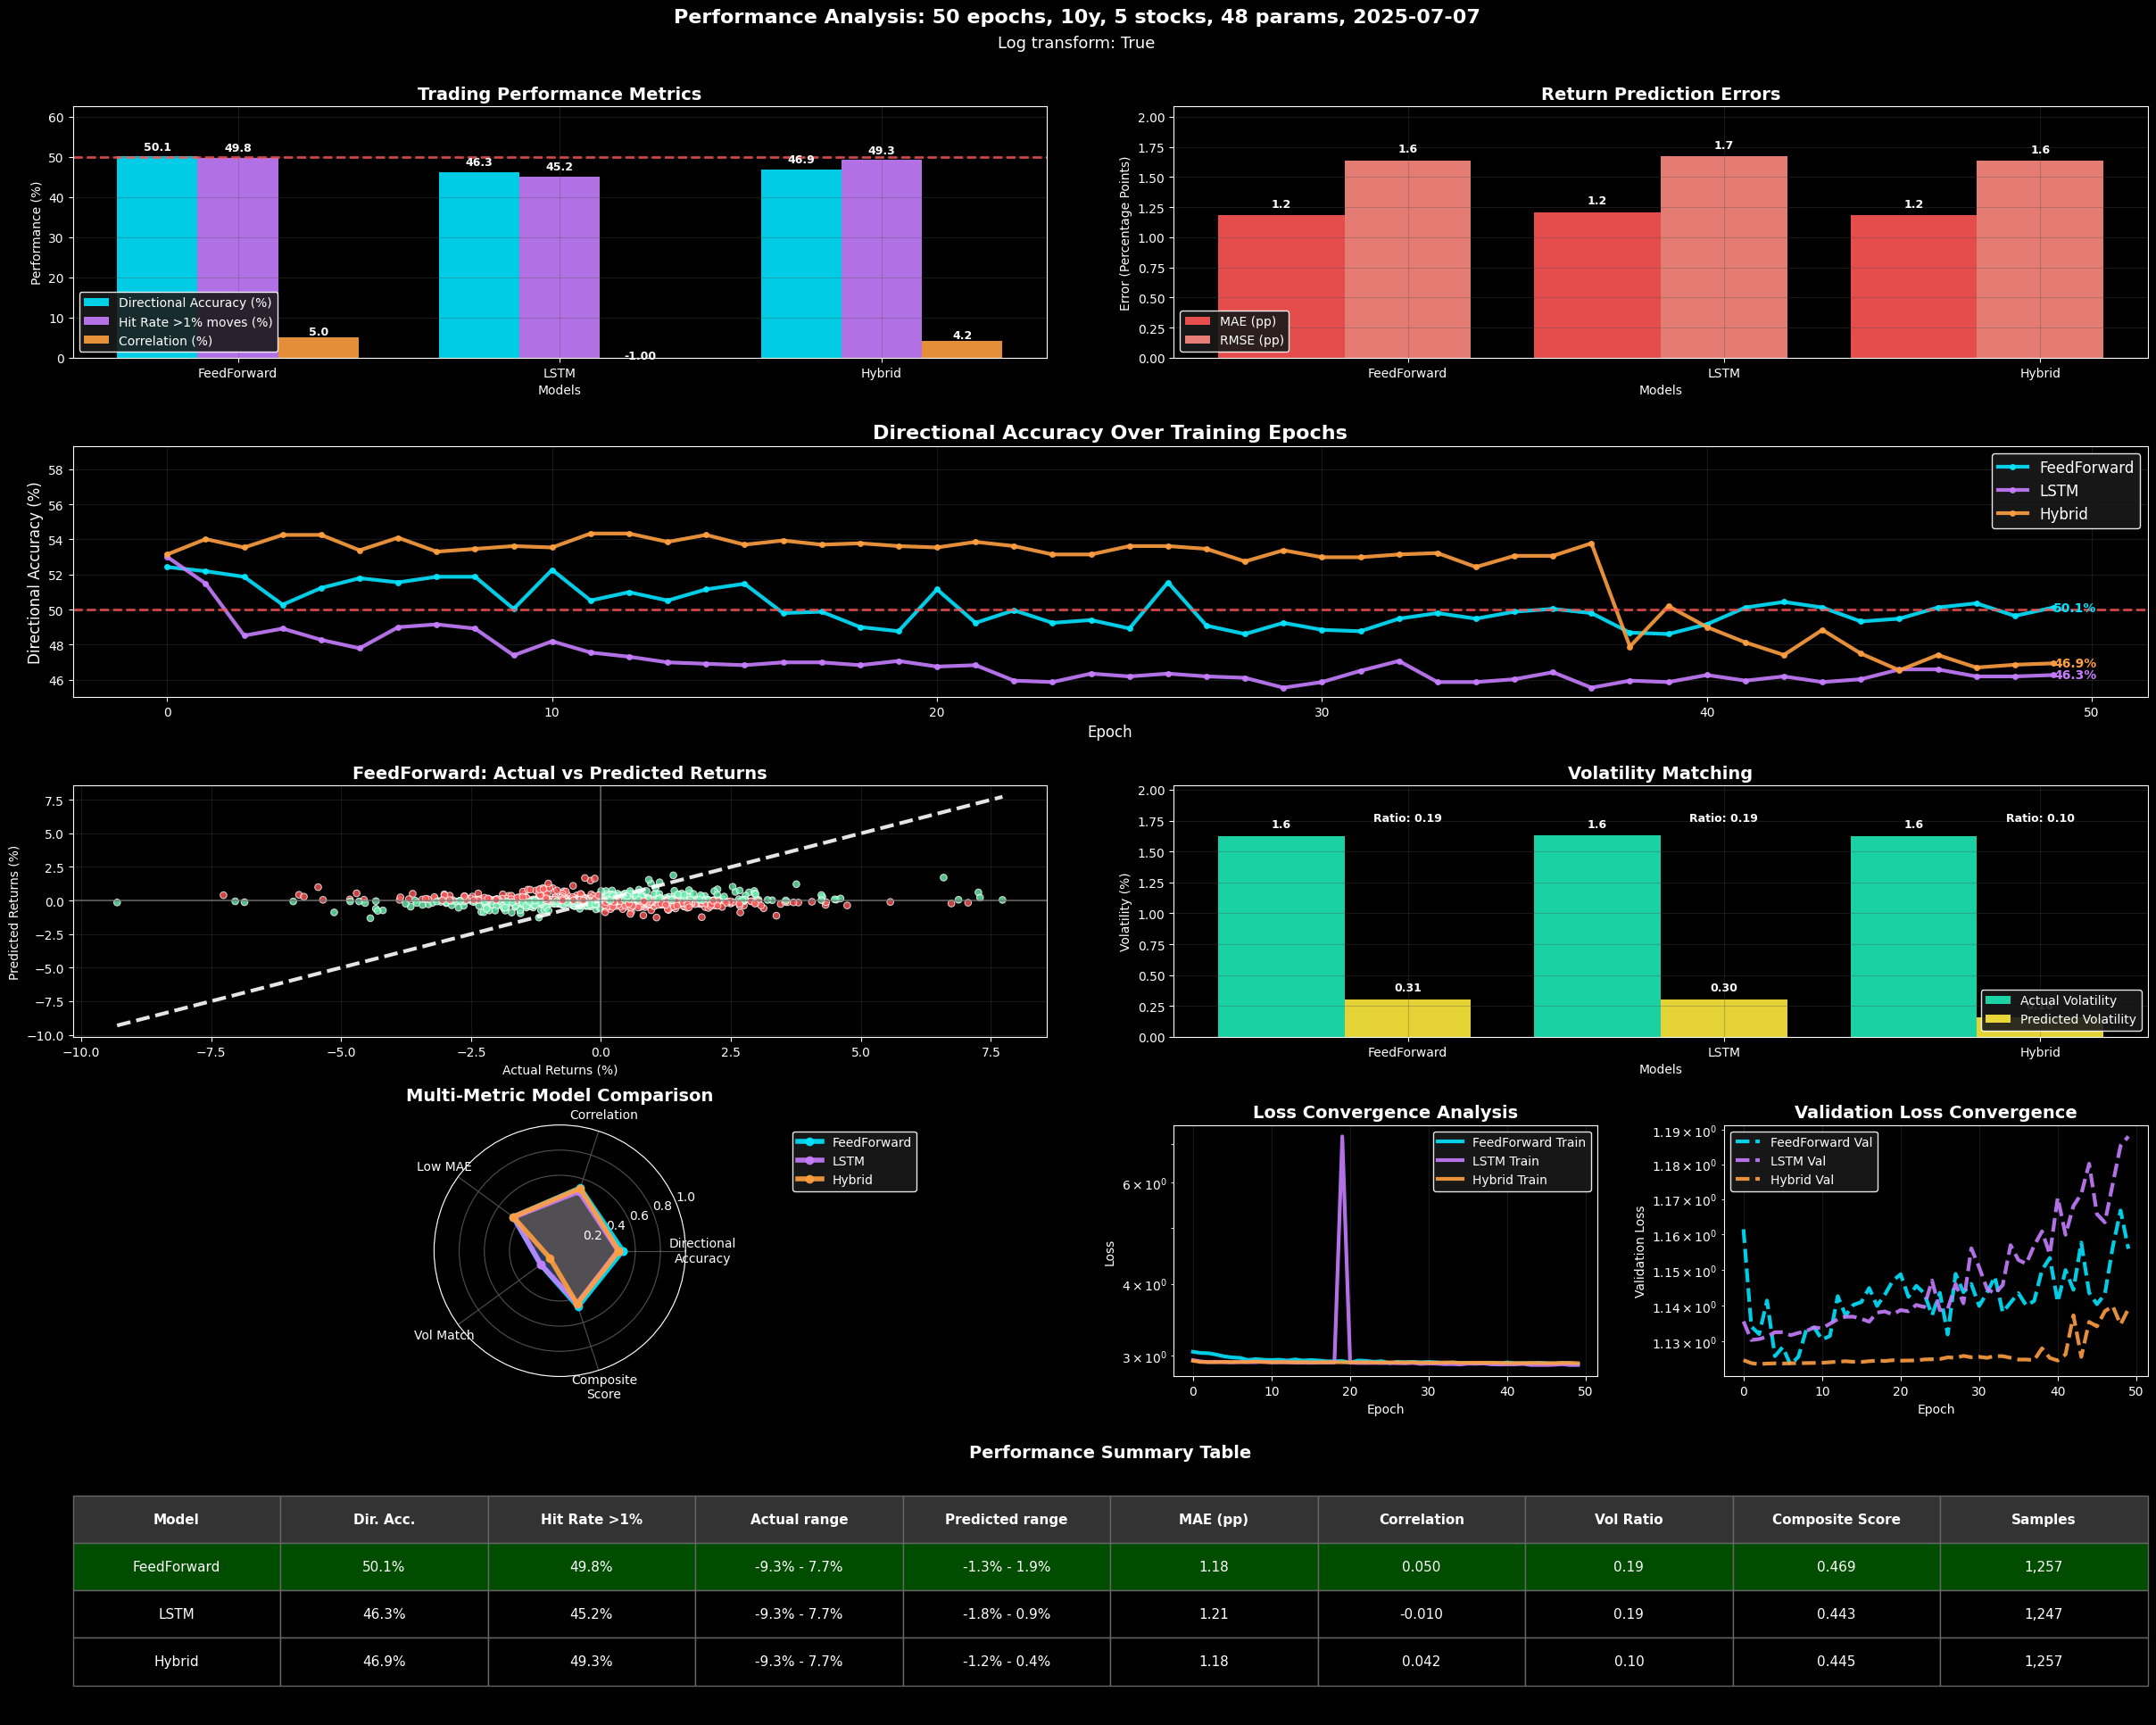

In [43]:
# IMPROVED PYTORCH RESULTS VISUALIZATION - TRUE BLACK DARK MODE

import matplotlib.pyplot as plt
import matplotlib

# Set dark theme for plots with TRUE BLACK backgrounds
plt.style.use('dark_background')
matplotlib.rcParams.update({
    'figure.facecolor': '#000000',      # Pure black
    'axes.facecolor': '#000000',        # Pure black
    'savefig.facecolor': '#000000',     # Pure black
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': 'white',
    'grid.color': '#404040',
    'axes.spines.bottom': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True
})

# Bright colors that pop against pure black
dark_colors = {
    'blue': '#00E5FF', 'purple': '#C77DFF', 'orange': '#FF9F40',
    'red': '#FF5555', 'coral': '#FF8A80', 'teal': '#1DE9B6',
    'yellow': '#FFEB3B', 'green': '#69F0AE'
}

# Define models dictionary and calculate metrics
models = {name: result['model'] for name, result in results.items()}
enhanced_metrics = calculate_enhanced_metrics(results, training_data)
composite_scores = {name: calculate_composite_score(metrics) for name, metrics in enhanced_metrics.items()}
best_model_enhanced = max(composite_scores, key=lambda k: composite_scores[k])


# Create visualization with accuracy plot
fig = plt.figure(figsize=(30, 22), facecolor='#000000')
gs = fig.add_gridspec(5, 4, hspace=0.35, wspace=0.3)

fig.suptitle(f'Performance Analysis: {global_epochs} epochs, {period}, {STOCK_LIMIT} stocks, {len(training_data["feature_names"])} params, {date.today()}', 
             fontsize=16, fontweight='bold', color='white')
fig.text(0.5, 0.96, f"Log transform: {training_data['log_transform_target']}", ha='center', fontsize=13, color='white')

models_list = list(enhanced_metrics.keys())

def create_bar_chart(ax, x_data, y_data_list, labels, colors, title, ylabel, loc, add_random_line=False):
    """Helper function to create consistent bar charts"""
    ax.set_facecolor('#000000')
    x = np.arange(len(x_data))
    width = 0.25 if len(y_data_list) == 3 else 0.4
    
    bars_list = []
    for i, (y_data, label, color) in enumerate(zip(y_data_list, labels, colors)):
        offset = (i - len(y_data_list)//2) * width
        bars = ax.bar(x + offset, y_data, width, label=label, alpha=0.9, color=color)
        bars_list.append(bars)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (0.05 if height < 10 else 1),
                    f'{height:.1f}' if height > 1 else f'{height:.2f}', 
                    ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')
    
    if add_random_line:
        ax.axhline(y=50, color='#FF5555', linestyle='--', alpha=0.8, linewidth=2)
    
    ax.set_title(title, fontweight='bold', fontsize=14, color='white')
    ax.set_xlabel('Models', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.set_ylim(0, np.max(y_data_list) + 0.25 * np.max(y_data_list))
    ax.set_xticks(x)
    ax.set_xticklabels(x_data, color='white')
    ax.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white', loc=loc)
    ax.grid(True, alpha=0.3, color='#505050')
    
    return bars_list

# 1. Trading Performance Dashboard (Top row, spans 2 columns)
ax1 = fig.add_subplot(gs[0, :2])
dir_acc = [enhanced_metrics[m]['directional_accuracy'] for m in models_list]
hit_rate_sig = [enhanced_metrics[m]['hit_rate_significant'] for m in models_list]
correlation = [enhanced_metrics[m]['correlation'] * 100 for m in models_list]

create_bar_chart(ax1, models_list, 
                [dir_acc, hit_rate_sig, correlation],
                ['Directional Accuracy (%)', 'Hit Rate >1% moves (%)', 'Correlation (%)'],
                [dark_colors['blue'], dark_colors['purple'], dark_colors['orange']],
                'Trading Performance Metrics', 'Performance (%)', 'lower left', add_random_line=True)

# 2. Return Prediction Quality (Top row, right)
ax2 = fig.add_subplot(gs[0, 2:])
mae_values = [enhanced_metrics[m]['return_mae'] for m in models_list]
rmse_values = [enhanced_metrics[m]['return_rmse'] for m in models_list]

create_bar_chart(ax2, models_list,
                [mae_values, rmse_values],
                ['MAE (pp)', 'RMSE (pp)'],
                [dark_colors['red'], dark_colors['coral']],
                'Return Prediction Errors', 'Error (Percentage Points)', 'lower left')

# 3. NEW: Directional Accuracy Over Epochs (Second row, spans full width)
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#000000')

colors_list = [dark_colors['blue'], dark_colors['purple'], dark_colors['orange']]
for i, (model_name, result) in enumerate(results.items()):
    if 'directional_accuracies' in result:
        epochs = range(len(result['directional_accuracies']))
        accuracies = result['directional_accuracies']
        
        ax3.plot(epochs, accuracies, label=f'{model_name}', 
                color=colors_list[i % len(colors_list)], linewidth=3, alpha=0.9, marker='o', markersize=4)
        
        # Add final accuracy value as text
        final_acc = accuracies[-1]
        ax3.text(len(epochs)-1, final_acc, f'{final_acc:.1f}%', 
                color=colors_list[i % len(colors_list)], fontweight='bold', fontsize=10,
                ha='left', va='center')

ax3.set_title('Directional Accuracy Over Training Epochs', fontweight='bold', fontsize=16, color='white')
ax3.set_xlabel('Epoch', color='white', fontsize=12)
ax3.set_ylabel('Directional Accuracy (%)', color='white', fontsize=12)
ax3.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white', fontsize=12)
ax3.grid(True, alpha=0.3, color='#505050')
ax3.axhline(y=50, color='#FF5555', linestyle='--', alpha=0.8, linewidth=2, label='Random Baseline (50%)')
ax3.axhline(y=60, color='#00FF00', linestyle=':', alpha=0.6, linewidth=1, label='Good Performance (60%)')

# Set y-axis limits for better visualization
if any('directional_accuracies' in result for result in results.values()):
    max_acc = max([max(result['directional_accuracies']) for result in results.values() if 'directional_accuracies' in result])
    ax3.set_ylim(45, max_acc + 5)

# 4. Best Model Detailed Analysis (Third row, left)
ax4 = fig.add_subplot(gs[2, :2])
ax4.set_facecolor('#000000')
if best_model_enhanced in enhanced_metrics:
    best_metrics = enhanced_metrics[best_model_enhanced]
    actual_clean = best_metrics['actual_clean']
    predicted_clean = best_metrics['predicted_clean']
    
    # Color code: green for correct direction, red for incorrect
    colors = [dark_colors['green'] if np.sign(a) == np.sign(p) else dark_colors['red'] 
              for a, p in zip(actual_clean, predicted_clean)]
    
    ax4.scatter(actual_clean, predicted_clean, c=colors, alpha=0.8, s=30, edgecolors='white', linewidth=0.7)
    
    # Perfect prediction line
    min_val, max_val = min(min(actual_clean), min(predicted_clean)), max(max(actual_clean), max(predicted_clean))
    ax4.plot([min_val, max_val], [min_val, max_val], color='white', linestyle='--', alpha=0.9, linewidth=3)
    
    ax4.set_title(f'{best_model_enhanced}: Actual vs Predicted Returns', fontweight='bold', fontsize=14, color='white')
    ax4.set_xlabel('Actual Returns (%)', color='white')
    ax4.set_ylabel('Predicted Returns (%)', color='white')
    ax4.grid(True, alpha=0.3, color='#505050')
    ax4.axhline(y=0, color='#808080', linestyle='-', alpha=0.6)
    ax4.axvline(x=0, color='#808080', linestyle='-', alpha=0.6)

# 5. Volatility Analysis (Third row, right)
ax5 = fig.add_subplot(gs[2, 2:])
actual_vols = [enhanced_metrics[m]['actual_vol'] for m in models_list]
predicted_vols = [enhanced_metrics[m]['predicted_vol'] for m in models_list]

create_bar_chart(ax5, models_list,
                [actual_vols, predicted_vols],
                ['Actual Volatility', 'Predicted Volatility'],
                [dark_colors['teal'], dark_colors['yellow']],
                'Volatility Matching', 'Volatility (%)', 'lower right')

# Add ratio labels for volatility
for i, (actual, predicted) in enumerate(zip(actual_vols, predicted_vols)):
    ratio = predicted / actual if actual > 0 else 0
    ax5.text(i, max(actual, predicted) + 0.1, f'Ratio: {ratio:.2f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='white')

# 6. Model Comparison Radar Chart (Fourth row, left)
ax6 = fig.add_subplot(gs[3, :2], projection='polar')
ax6.set_facecolor('#000000')

metrics_names = ['Directional\nAccuracy', 'Correlation', 'Low MAE', 'Vol Match', 'Composite\nScore']
angles = np.linspace(0, 2 * np.pi, len(metrics_names), endpoint=False).tolist() + [0]

for i, model in enumerate(models_list):
    if model in enhanced_metrics:
        m = enhanced_metrics[model]
        values = [
            m['directional_accuracy'] / 100,
            (m['correlation'] + 1) / 2,
            1 / (1 + m['return_mae']),
            1 - abs(1 - m['vol_ratio']),
            composite_scores[model]
        ] + [m['directional_accuracy'] / 100]  # Close the circle
        
        ax6.plot(angles, values, 'o-', linewidth=4, label=model, alpha=0.9, color=colors_list[i % len(colors_list)])
        ax6.fill(angles, values, alpha=0.2, color=colors_list[i % len(colors_list)])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics_names, color='white')
ax6.set_ylim(0, 1)
ax6.set_title('Multi-Metric Model Comparison', fontweight='bold', fontsize=14, pad=20, color='white')
ax6.legend(loc='upper left', bbox_to_anchor=(1.4, 1.0), framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')
ax6.grid(True, color='#505050')
ax6.tick_params(colors='white')

# 7. Training Loss Evolution (Fourth row, right)
ax7 = fig.add_subplot(gs[3, 2])
ax7.set_facecolor('#000000')

for i, (name, result) in enumerate(results.items()):
    epochs_range = range(len(result['train_losses']))
    ax7.plot(epochs_range, result['train_losses'], label=f'{name} Train', alpha=0.9, linewidth=3, color=colors_list[i % len(colors_list)])

ax7.set_title('Loss Convergence Analysis', fontweight='bold', fontsize=14, color='white')
ax7.set_xlabel('Epoch', color='white')
ax7.set_ylabel('Loss', color='white')
ax7.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')
ax7.grid(True, alpha=0.3, color='#505050')
ax7.set_yscale('log')

# 8. Validation Loss Evolution (Fourth row, far right)
ax8 = fig.add_subplot(gs[3, 3])
ax8.set_facecolor('#000000')

# Plot only validation loss
for i, (name, result) in enumerate(results.items()):
    epochs_range = range(len(result['test_losses']))
    ax8.plot(epochs_range, result['test_losses'], label=f'{name} Val', linestyle='--', alpha=0.9, linewidth=3, color=colors_list[i % len(colors_list)])

ax8.set_title('Validation Loss Convergence', fontweight='bold', fontsize=14, color='white')
ax8.set_xlabel('Epoch', color='white')
ax8.set_ylabel('Validation Loss', color='white')
ax8.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')
ax8.grid(True, alpha=0.3, color='#505050')
ax8.set_yscale('log')

# 8. Performance Summary Table (Bottom row, spans full width)
ax9 = fig.add_subplot(gs[4, :])
ax9.axis('tight')
ax9.axis('off')
ax9.set_facecolor('#000000')

headers = ['Model', 'Dir. Acc.', 'Hit Rate >1%', 'Actual range', 'Predicted range', 'MAE (pp)', 'Correlation', 'Vol Ratio', 'Composite Score', 'Samples']
table_data = []

for model in models_list:
    if model in enhanced_metrics:
        m = enhanced_metrics[model]
        table_data.append([
            model,
            f"{m['directional_accuracy']:.1f}%",
            f"{m['hit_rate_significant']:.1f}%",
            f"{np.min(m['actual_clean']):.1f}% - {np.max(m['actual_clean']):.1f}%",
            f"{np.min(m['predicted_clean']):.1f}% - {np.max(m['predicted_clean']):.1f}%",
            f"{m['return_mae']:.2f}",
            f"{m['correlation']:.3f}",
            f"{m['vol_ratio']:.2f}",
            f"{composite_scores[model]:.3f}",
            f"{m['samples']:,}"
        ])

table = ax9.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style the table
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#333333')
    else:
        cell.set_text_props(color='white')
        cell.set_facecolor('#000000')
    cell.set_edgecolor('#666666')
    cell.set_linewidth(1)

# Highlight best model row
best_row_idx = models_list.index(best_model_enhanced) + 1
for j in range(len(headers)):
    table[(best_row_idx, j)].set_facecolor('#004d00')

ax9.set_title('Performance Summary Table', fontweight='bold', fontsize=14, color='white')

plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Move plots closer to the title
save_path = f'results/{date.today().strftime("%Y-%m-%d_%H-%M")}_{period}_{max(epochs)}e_{"500" if USE_FULL_DATASET else STOCK_LIMIT}s.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()